In [1]:
import numpy as np
from tifffile import imread
from matplotlib import pyplot as plt
from nanopyx.core.transform._le_esrrf import eSRRF
from nanopyx.core.analysis._le_pearsons_correlation import PearsonsCorrelation
from nanopyx.core.transform._le_interpolation_catmull_rom import ShiftAndMagnify

Optional dependency Cupy is not installed. Cupy implementations will be ignored.


In [30]:
interp = ShiftAndMagnify()
mag = 5
image = imread("/Users/bsaraiva/Code/NanoPyx/SMLM.tif")
array_1 = interp.run(np.mean(image, axis=0).astype(np.float32), 0, 0, mag, mag)[0]
esrrf = eSRRF()
array_2 = interp.run(np.mean(esrrf.run(image), axis=0), 0, 0, mag, mag)[0]
fixed_sigma = 2
# pc = PearsonsCorrelation(clear_benchmarks=True, testing=True)

# for i in range(1):
#     pc.benchmark(array_1, array_2)

Querying the Agent...
Agent: ShiftMagnify_catmull_rom using Threaded ran in 0.00475299999999379 seconds
Run type Threaded was delayed in the previous run. Delay factor: 1.9753530959247254, Delay probability: 0.46708232954459294
Querying the Agent...
Found:  Buffer size is larger than device maximum memory allocation size
Reducing maximum buffer size and trying again...
Found:  Buffer size is larger than device maximum memory allocation size
Reducing maximum buffer size and trying again...
Agent: eSRRF_ST using OpenCL_Apple M1 ran in 3.1680290829999933 seconds
Querying the Agent...
Agent: ShiftMagnify_catmull_rom using Threaded_dynamic ran in 0.05858187500001577 seconds


In [31]:
from nanopyx.core.transform._le_error_map import ErrorMap

error = ErrorMap()
for i in range(3):
    error.benchmark(array_1, array_2, fixedSigma=fixed_sigma)

Agent: ShiftMagnify_catmull_rom using OpenCL_Apple M1 ran in 0.027328208999989556 seconds
Agent: PearsonsCorrelation using OpenCL_Apple M1 ran in 0.16160650000000487 seconds
Agent: ErrorMap using OpenCL_Apple M1 ran in 1.091667292000011 seconds
Agent: ShiftMagnify_catmull_rom using Threaded ran in 0.05064345900001399 seconds
Agent: PearsonsCorrelation using Threaded ran in 0.004550457999982882 seconds
Agent: ErrorMap using Threaded ran in 0.9408907909999868 seconds
Agent: ShiftMagnify_catmull_rom using Unthreaded ran in 0.22802004199999715 seconds
Agent: PearsonsCorrelation using Unthreaded ran in 0.02292612499999791 seconds
Agent: ErrorMap using Unthreaded ran in 1.1160085419999746 seconds
Fastest run type: Threaded
Slowest run type: Unthreaded
Threaded is 1.16x faster than OpenCL_Apple M1
Threaded is 1.19x faster than Unthreaded
OpenCL_Apple M1 is 1.02x faster than Unthreaded
Agent: ShiftMagnify_catmull_rom using OpenCL_Apple M1 ran in 0.025222958000000517 seconds
Agent: PearsonsCorr

Agent: ShiftMagnify_catmull_rom using Unthreaded ran in 0.24991920800002276 seconds
Agent: PearsonsCorrelation using Unthreaded ran in 0.02297416700000099 seconds
Agent: ErrorMap using Unthreaded ran in 1.1574762919999841 seconds
60.53594054490481 0.9027699354007644


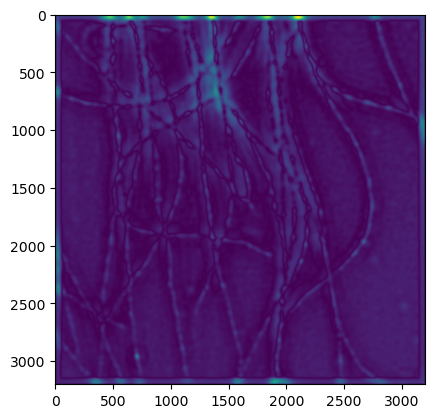

In [32]:
im, rse, rsp = error.run(array_1, array_2, fixedSigma=fixed_sigma, run_type="Unthreaded")
plt.imshow(im)
print(rse, rsp)

Agent: ShiftMagnify_catmull_rom using OpenCL_Apple M1 ran in 0.025643999999999778 seconds
Agent: PearsonsCorrelation using OpenCL_Apple M1 ran in 0.15049595799999338 seconds
Agent: ErrorMap using OpenCL_Apple M1 ran in 1.0655533750000075 seconds
60.53596675931074 0.8897173303677025


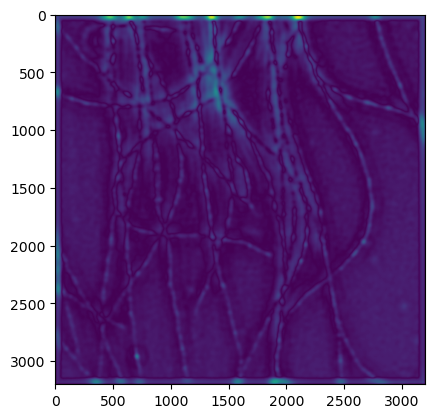

In [33]:
im, rse, rsp = error.run(array_1, array_2, fixedSigma=fixed_sigma, run_type="OpenCL_Apple M1")
plt.imshow(im)
print(rse, rsp)

Agent: ShiftMagnify_catmull_rom using Threaded ran in 0.05278591699999424 seconds
Agent: PearsonsCorrelation using Threaded ran in 0.006196334000009074 seconds
Agent: ErrorMap using Threaded ran in 0.9368645000000129 seconds
60.53593247893147 0.8898740849031459


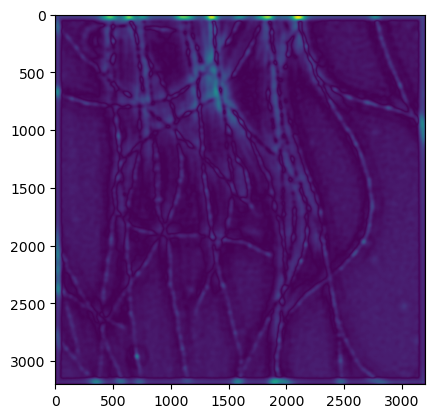

In [34]:
im, rse, rsp = error.run(array_1, array_2, fixedSigma=fixed_sigma, run_type="Threaded")
plt.imshow(im)
print(rse, rsp)